In [36]:
# Import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [38]:
# Load data
df = pd.read_csv("D:Goutham/Projects/Python/Project 3/Multi Linear Regression - Assignment -3_4/3. Multi Linear Regression/50_Startups_Project/50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [40]:
# pre-processing - Handling categorical values
df = pd.get_dummies(df, drop_first=True)
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


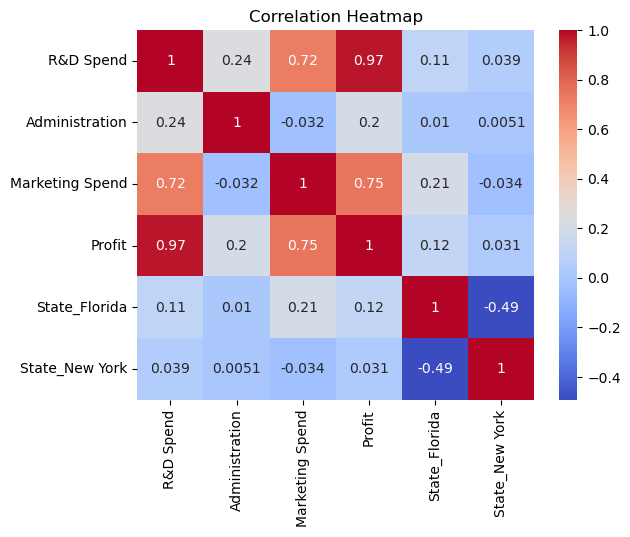

In [41]:
# Correlation
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

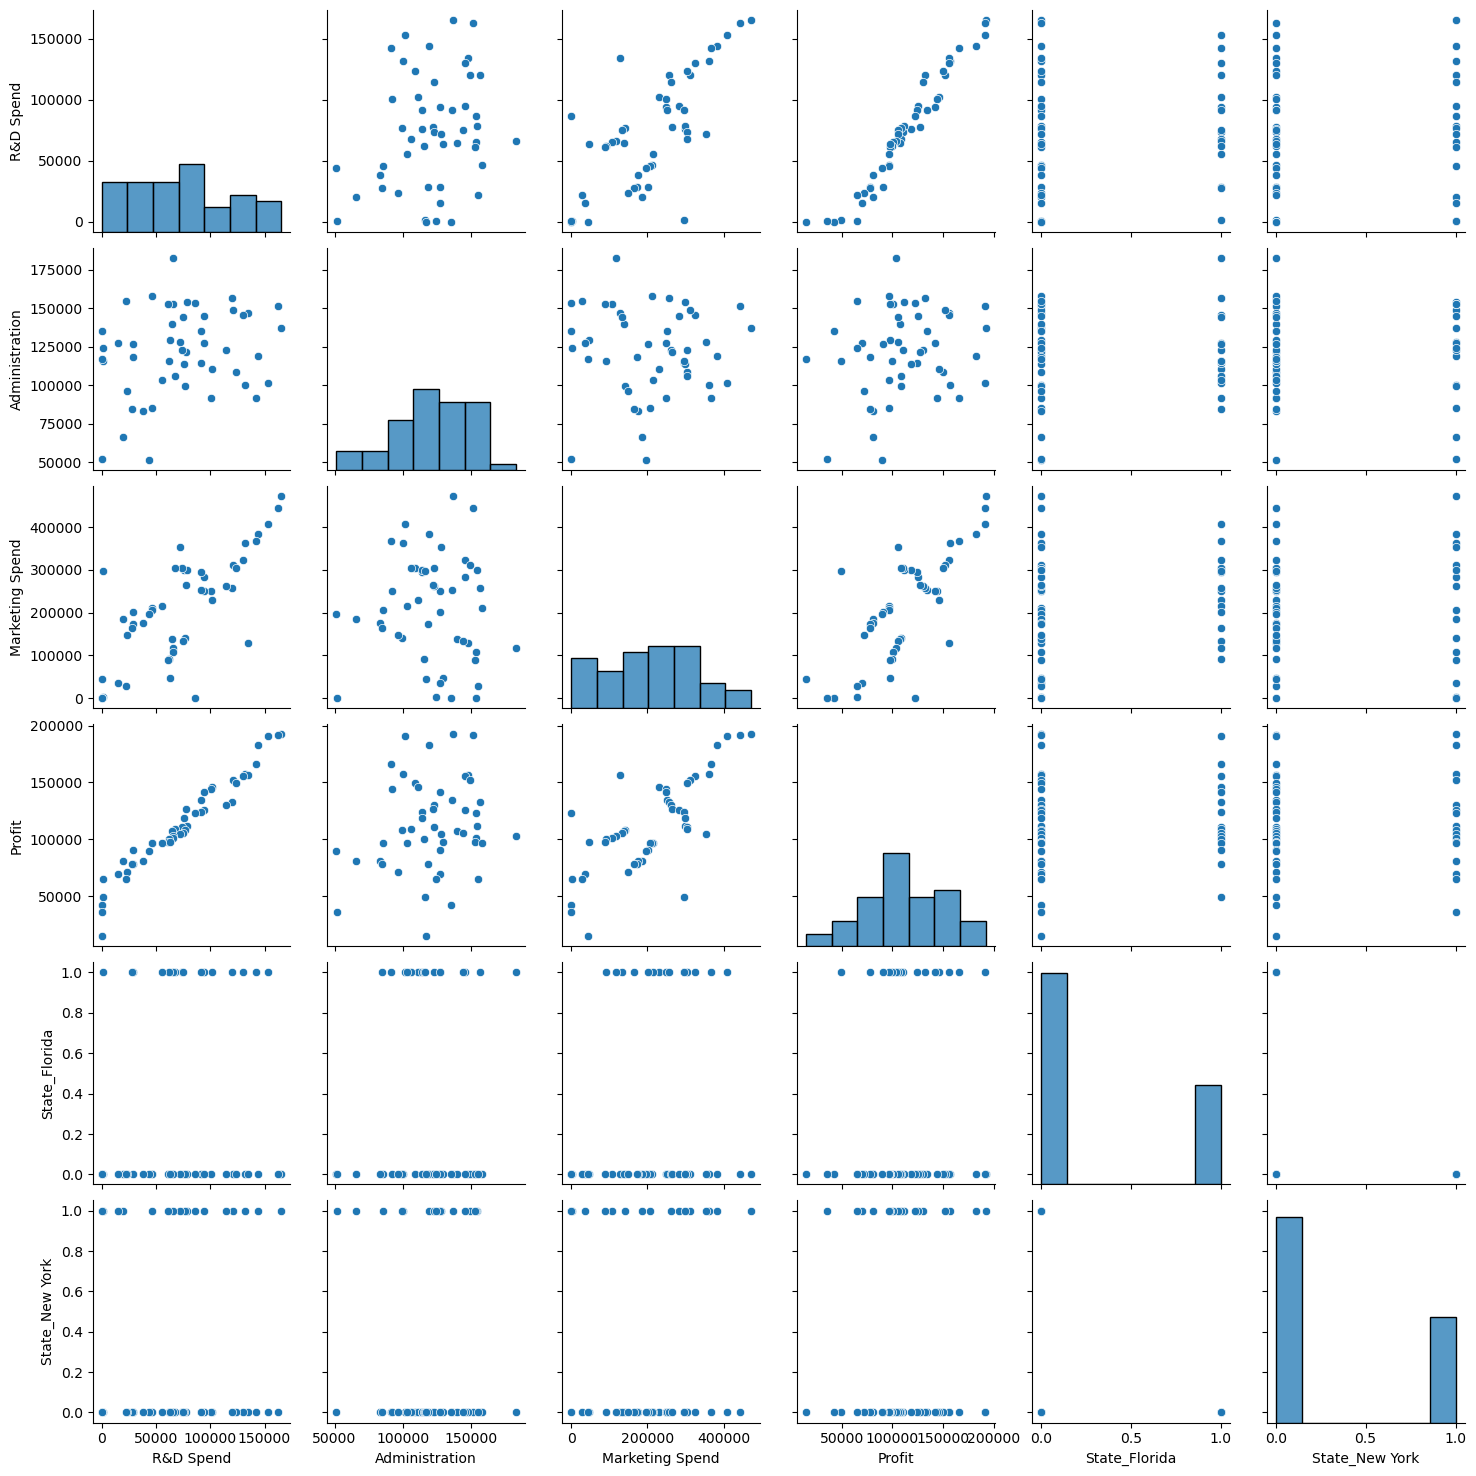

In [42]:
# Pairplot
sns.pairplot(df)
plt.show()

In [43]:
# Model building
X = df.drop('Profit', axis=1)
y = df['Profit']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
r2

0.9507524843355148

In [44]:
# Log X Transformation
X_log = np.log(X + 1)
model_log = LinearRegression().fit(X_log, y)
r2_log = r2_score(y, model_log.predict(X_log))

In [45]:
# Log y Transformation
y_log = np.log(y)
model_exp = LinearRegression().fit(X, y_log)
r2_exp = r2_score(y, np.exp(model_exp.predict(X)))

In [46]:
# Comparing the models
results = pd.DataFrame({
    'Model': ['Linear', 'Log_X', 'Log_Y'],
    'R2': [r2, r2_log, r2_exp]
})

results

,Model,R2
0,Linear,0.950752
1,Log_X,0.537025
2,Log_Y,0.853832


# Model Selection
The linear regression model produced the highest R² score (~0.95).
Transformations did not significantly improve performance.
Therefore, the linear model is selected.

In [47]:
# Feature importance
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coeff_df

,Feature,Coefficient
0,R&D Spend,0.806023
1,Administration,-0.027004
2,Marketing Spend,0.026980
3,State_Florida,198.788793
4,State_New York,-41.887019


R&D Spend has the strongest positive impact on profit.

In [50]:
# Predictions
new_data = X.head(3)

predictions = model.predict(new_data)

output = pd.DataFrame({
    'Actual': y.head(3),
    'Predicted': predictions
})

output.to_csv("D:/Goutham/Projects/Python/Project 3/Multi Linear Regression - Assignment -3_4/3. Multi Linear Regression/50_Startups_Project/startup_predictions.csv", index=False)